# Direction

well due to poor planning I had far less time to think of intresting ways to itterate or experiment with the core design of ACO, this can be also attributed to the fact that ACO, is a far exactly defined algorithm in terms of its description on the [lecture site](https://ktiml.mff.cuni.cz/~pilat/cs/prirodou-inspirovane-algoritmy/hejna-kolonie/). Which describes only the attractiveness heuristic and some constants as its parameters. 
this obviusly doesnt mean that there arent any ways to play with it, just that they feel more limited.

nonetheless I did still make some systems to experiment with here.

an example of this would be the stagnation function which attempts to modify $\alpha$ and $\beta$ mid runtime to increase experimentation when the system begins to stagnate
other then this I also implemented a secondary pathing based decay, which should insentivise path experimentation a bit.

### Libraries

some libraries added as they were needed

In [49]:
from collections import namedtuple
import math
import functools
import os

import time

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib import collections as mc

# Problem


the problem is a [simplification of the Vehicle routing problem](https://kam.mff.cuni.cz/~lorenc/teach/PIA_hw/homeworks-routing.html).

for this task I decided to represent it with a class:

In [50]:
Vertex = namedtuple("Vertex", ["id", "x", "y", "demand"])

class RoutingGraph:
    def __init__(self, file_path):
        self.vertices = []
        self.name = file_path
        self.vehicle_size = 1000

        if file_path.lower().endswith(".xml"):
            with open(file_path, encoding="utf-8") as xml_file:
                xml_text = xml_file.read()

            def tag_value(source, tag, start=0):
                opening = f"<{tag}>"
                closing = f"</{tag}>"
                start_tag = source.find(opening, start)
                if start_tag == -1:
                    return None
                value_start = start_tag + len(opening)
                end_tag = source.find(closing, value_start)
                if end_tag == -1:
                    return None
                return source[value_start:end_tag].strip()

            def attr_value(header, attr_name):
                token = f'{attr_name}="'
                attr_start = header.find(token)
                if attr_start == -1:
                    return None
                value_start = attr_start + len(token)
                value_end = header.find('"', value_start)
                if value_end == -1:
                    return None
                return header[value_start:value_end]

            def iter_blocks(source, tag):
                start_token = f"<{tag} "
                end_token = f"</{tag}>"
                search_pos = 0
                while True:
                    block_start = source.find(start_token, search_pos)
                    if block_start == -1:
                        return
                    block_end = source.find(end_token, block_start)
                    if block_end == -1:
                        return
                    open_end = source.find(">", block_start)
                    header = source[block_start:open_end + 1]
                    body = source[open_end + 1:block_end]
                    yield header, body
                    search_pos = block_end + len(end_token)

            instance_name = tag_value(xml_text, "name")
            if instance_name:
                self.name = instance_name

            capacity = tag_value(xml_text, "capacity")
            if capacity is not None:
                self.vehicle_size = float(capacity)

            demands = {}
            for request_header, request_body in iter_blocks(xml_text, "request"):
                node_id = attr_value(request_header, "node")
                quantity = tag_value(request_body, "quantity")
                if node_id is not None and quantity is not None:
                    demands[node_id] = float(quantity)

            nodes = []
            for node_header, node_body in iter_blocks(xml_text, "node"):
                node_id = attr_value(node_header, "id")
                x = tag_value(node_body, "cx")
                y = tag_value(node_body, "cy")
                if node_id is not None and x is not None and y is not None:
                    nodes.append((int(node_id), node_id, float(x), float(y)))

            nodes.sort(key=lambda n: n[0])
            for _, node_id, x, y in nodes:
                demand = demands.get(node_id, 0.0)
                self.vertices.append(Vertex(node_id, x, y, demand))

            if self.vertices:
                depot = self.vertices[0]
                self.vertices[0] = Vertex(depot .id, depot.x, depot.y, 0.0)
            return

        with open(file_path) as cities_file:
            csv_reader = csv.reader(cities_file, delimiter=',')
            for row in csv_reader:
                self.vertices.append(Vertex(row[0], float(row[2]), float(row[1]), float(row[3])))
    
    def __len__(self):
        return len(self.vertices)
    
    def __getitem__(self, key):
        return self.vertices[key]
    
    def __iter__(self):
        return iter(self.vertices)
    
    def __str__(self):
        return f"RoutingGraph with {len(self.vertices)} vertices from {self.name}"
    
    @functools.lru_cache(maxsize=None)
    def distance(self, a, b):
        v1 = self.vertices[a]
        v2 = self.vertices[b]
        return math.sqrt(((v1.x - v2.x) * (v1.x - v2.x)) + ((v1.y - v2.y) * (v1.y - v2.y)))

    def __call__(self, *args):
        if len(args) == 2:
            return self.distance(args[0], args[1])

        if len(args) != 1:
            raise TypeError("RoutingGraph expects Routing(a, b) or Routing(path)")

        path = args[0]
        total_distance = 0.0
        for a, b in zip(path[:-1], path[1:]):
            total_distance += self.distance(a, b)
        return total_distance

    def dist_sum(self):
        return sum(self.distance(0, i) for i in range(1, len(self.vertices)))

note: this the main place I used generative AI, which is to say to generate the `__init__` function.

# Design Structure

most of the structure is again, a straight-ish copy of your design from the notes, with the major exception that this structure felt far less, meleable in terms of modulisation

the only point where I play a bit with it is with the implementation of stagnation prevention.

### Anti Stagnation function

as was stated the goal of this function is to define how stagnant the system currently is

the function takes 3 values the last stagnation value, the last best path lenght and the new best path lenght
and depending on the values it modifies the stagnation value.

a stagnation value below $1$ means the system is slowing experimentation and higher means its increasing it.

In [51]:
# intended for testing purpuses, does nothing.
def identity(primaryinput=None, *regparams, **params):
    return primaryinput

def examplestag(stagnation, best_gen_length, best_length, stag_threshold=0.05):
    if best_gen_length < best_length * (1 - stag_threshold):
        stagnation *= 0.5 + 0.5 * (best_gen_length / best_length)
    elif best_gen_length > best_length * (1 + stag_threshold):
        stagnation *= 0.5 + 0.5 * (best_gen_length / best_length)
    else:
        stagnation = np.sqrt(stagnation)
    stagnation = max(0.5, stagnation) # prevent LOW stagnation
    stagnation = min(2, stagnation) # prevent HIGH stagnation 
    return stagnation


### Main class Code

In [52]:
class Ant_Solver:
    def __init__(self):
        pass

    def setup_pheromone(self):
        N = len(self.Routing)
        self.pheromones = self.initpher * np.ones(shape=(N,N))

    def setup(self, routs, number_of_ants=10, max_iterations=1000, alpha=1, beta=3, Q=100, t_decay=0.8, p_decay=0.8, init_pheromone=0.01, stag_funct=identity):
        self.Routing = routs
        self.number_of_ants = number_of_ants
        self.max_iterations = max_iterations
        self.base_alpha = alpha
        self.base_beta = beta
        self.alpha = alpha
        self.beta = beta
        self.Q = Q
        self.t_decay = t_decay
        self.p_decay = p_decay
        self.initpher = init_pheromone
        self.best_solution = None
        self.best_length = routs.dist_sum() * 2 # approximates a trivial solution
        self.last_worst_length = routs.dist_sum() * 2
        self.last_best_length = routs.dist_sum() * 2
        self.fitgraph = list()
        self.aco_rng = np.random.default_rng()
        self.stag_function = stag_funct
        self.stagnation = 1


        self.setup_pheromone()
    
    def update_pheromone(self, solutions, solution_lengths):
        pheromone_update = np.zeros(shape=self.pheromones.shape)
        for solution, solution_length in zip(solutions, solution_lengths):
            for a, b in zip(solution[:-1], solution[1:]):
                pheromone_update[a, b] += self.Q / solution_length
        
        self.pheromones = (1 - self.t_decay) * self.pheromones + pheromone_update

    @functools.lru_cache(maxsize=None)
    def sexyness(self, a, b):
        return 1 / self.Routing(a, b)

    # Probability of selecting b right after a
    def get_prob(self, a, b):
        sexns = self.sexyness(a, b)
        tau = self.pheromones[a, b]
        ret = pow(tau, self.alpha) * pow(sexns, self.beta)
        return ret if ret > 1e-6 else 1e-6
    
    def generate_solution(self):
        number_of_vertices = len(self.Routing)
        unfullfilled = list(range(1, number_of_vertices))
        solution = [0] # zero index vertex is always the depot
        capacity_left = self.Routing.vehicle_size
        
        while unfullfilled:
            a = solution[-1]
            fullfillable = [b for b in unfullfilled if self.Routing[b].demand <= capacity_left]

            if a != 0:
                fullfillable.append(0) # we can always return to the depot
            elif not fullfillable and unfullfilled:
                raise ValueError("No fullfillable vertices left, but unfullfilled is not empty. This should not happen!")
                
            probs = np.array(list(map(lambda x: self.get_prob(a, x), fullfillable)))
            selected = self.aco_rng.choice(fullfillable, p=(probs / np.sum(probs))) # Edge selection
            solution.append(selected)
            if selected == 0:
                capacity_left = self.Routing.vehicle_size
                # refill car
            else:
                capacity_left -= self.Routing[selected].demand
                unfullfilled.remove(selected)
        if solution[-1] != 0:
            solution.append(0) # return to depot at the end if not already there
        for a, b in zip(solution[:-1], solution[1:]):
            self.pheromones[a, b] *= (1 - self.p_decay) # pheromone decay on the path of the generated solution
            
        return solution
    
    def generate_solutions(self):
        for _ in range(self.number_of_ants):
            yield self.generate_solution()
    
    def validate_solution(self, solution):
        return solution[0] == 0 and \
        all(self.Routing[solution[i]].demand <= self.Routing.vehicle_size for i in range(1, len(solution))) and \
        all(solution[i] != solution[i + 1] for i in range(len(solution) - 1))

    def run_generation(self):
        candidate_solutions = list(self.generate_solutions())
        valid_solutions = [solution for solution in candidate_solutions if self.validate_solution(solution)]
        if not valid_solutions:
            raise ValueError("No valid solutions generated in this generation.")

        solution_lengths = [self.Routing(solution) for solution in valid_solutions]
        self.update_pheromone(valid_solutions, solution_lengths)
        best_gen_solution = None
        best_gen_length = float("inf")
        worst_gen_length = float(0)

        for candidate_solution, candidate_length in zip(valid_solutions, solution_lengths):
            if candidate_length < best_gen_length:
                best_gen_length = candidate_length
                best_gen_solution = candidate_solution
            worst_gen_length = max(worst_gen_length, candidate_length)

        self.stagnation = self.stag_function(self.stagnation, best_gen_length, self.last_best_length)
        self.last_best_length = best_gen_length
        self.last_worst_length = worst_gen_length
        self.alpha = self.base_alpha / self.stagnation
        self.beta = self.base_beta * self.stagnation

        if best_gen_length < self.best_length:
            self.best_length = best_gen_length
            self.best_solution = best_gen_solution

        self.fitgraph.append(best_gen_length)
        
        return np.min(solution_lengths), np.mean(solution_lengths), np.max(solution_lengths)
    
    def run(self, log_rate = 0):
        if log_rate != 0:
            print("Iteration\tMinimum value\tMean value\tMaximum value")
        for i in range(self.max_iterations):
            min_val, mean_val, max_val = self.run_generation()
            if log_rate != 0 and ((i % log_rate == 0) or (i == self.max_iterations - 1)):
                print(f"{i:8}:\t{min_val:5.8f}\t{mean_val:5.8f}\t{max_val:5.8f}")

    def giveStats(self):
        return self.best_solution, self.pheromones, self.fitgraph

# Experimentation

## Experimentation Utilities

For the purpuses of experimentation I import and modify the same function I used in the last exercise

In [53]:
def RunExperiment(ProblemSpecs, Specs, report_interval=10):
    Experiment = Ant_Solver()
    Experiment.setup(ProblemSpecs, **Specs)
    Experiment.run(log_rate=report_interval)
    best_solution, pheromones, fitgraph = Experiment.giveStats()
    best_distance = ProblemSpecs(best_solution)
    return best_distance, best_solution, fitgraph, pheromones

In [54]:
ExperimentVariables = [
    ("number_of_ants", [
            10,
        ]),
    ("max_iterations", [
            100
        ]),
    ("alpha",
            list(range(1, 6, 1))
        ),
    ("beta",
            list(range(1, 6, 1))
        ),
    ("Q",
            list(range(50, 300, 50))
        ),
    ("t_decay", 
            [ 1 - 0.05*i for i in range(5)]
        ),
    ("p_decay", 
            [ 0.75 + 0.05*i for i in range(5)]
        ),
    ("stag_funct", [
            identity,
            examplestag,
        ]),
]

In [55]:
def stringindex(index):
    result = ""
    for i in range(len(index)):
        result += str(index[i])
        if i != len(index)-1:
            result += "."   
    return result

def makeindex(Varlist):
    index = [0 for _ in range(len(Varlist))]
    return index

def indexsize(Varlist):
    index = 1
    for i in range(len(Varlist)):
        index *= len(Varlist[i][1])
    return index

# generates the current index configuration AND pushes the index
def getandpushindex(index, VarList, Push=True):
    choice = {}
    pushing = Push
    for i in range(len(index)):
        Param = VarList[i]
        ind = index[i]

        choice[Param[0]] = Param[1][ind]
        if pushing:
            if ind + 1 < len(Param[1]): # figure out if we are overflowing
                index[i] = ind + 1 
                pushing=False
            else:
                index[i] = 0
    return choice, index, pushing

In [56]:
def ProcessData(dataset):
    # Convert dataset to DataFrame
    df = pd.DataFrame(dataset)
    df = df.drop('pheromones', axis=1) if 'pheromones' in df.columns else df
    df_display = df.drop('data', axis=1) if 'data' in df.columns else df

    df_sorted = df_display.sort_values('score', ascending=False)
    print("\nExperiment Results Sorted by Score:")
    print(df_sorted.to_string(index=False))

    print(f"\nSummary Statistics:")
    print(f"Total Experiments: {len(df)}")
    print(f"Best Score: {df['score'].max()}")
    print(f"Worst Score: {df['score'].min()}")
    print(f"Average Score: {df['score'].mean():.2f}")
    print(f"Average Time: {df['time'].mean():.2f}s")
    return df


In [57]:
def ShowData(df):
    # Create the plot
    plt.figure(figsize=(12, 8))

    # Plot each experiment's fitness evolution
    for i, row in df.iterrows():
        plt.plot(row['data'], label=f"Config {row['index']} (Score: {row['score']})", alpha=0.7)

    # Customize the plot
    plt.title('Fitness Evolution Across All Experiments', fontsize=14)
    plt.xlabel('Generation', fontsize=12)
    plt.ylabel('Fitness Score', fontsize=12)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    # Show the plot
    plt.show()

    # Optional: Create a summary plot showing only best/worst/average
    plt.figure(figsize=(10, 6))

    # Calculate average fitness per generation
    all_data = [row['data'] for _, row in df.iterrows()]
    min_length = min(len(d) for d in all_data)
    truncated_data = [d[:min_length] for d in all_data]

    avg_fitness = np.mean(truncated_data, axis=0)
    best_fitness = np.max(truncated_data, axis=0)
    worst_fitness = np.min(truncated_data, axis=0)

    plt.plot(avg_fitness, label='Average Fitness', linewidth=2, color='blue')
    plt.plot(best_fitness, label='Best Fitness', linewidth=2, color='green')
    plt.plot(worst_fitness, label='Worst Fitness', linewidth=2, color='red')

    plt.fill_between(range(len(avg_fitness)), worst_fitness, best_fitness, alpha=0.2, color='blue')

    plt.title('Fitness Evolution Summary', fontsize=14)
    plt.xlabel('Generation', fontsize=12)
    plt.ylabel('Fitness Score', fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


    plt.figure(figsize=(8, 6))
    plt.scatter(df['time'], df['score'], alpha=0.6)

    # Add labels for each point
    for i, row in df.iterrows():
        plt.annotate(row['index'], (row['time'], row['score']), 
                    xytext=(5, 5), textcoords='offset points', fontsize=8)

    plt.title('Score vs Execution Time')
    plt.xlabel('Time (seconds)')
    plt.ylabel('Final Score')
    plt.grid(True, alpha=0.3)
    plt.show()


In [58]:
def AnaliseConfiguration(ProblemSpecs, Specs, num = 10, nameprefix = ""):
    dataset = []
    printed = 0
    print("_"*20)
    for iter in range(num):
        start_time = time.perf_counter()  # High-precision timer
        score, _, data, Pher = RunExperiment(ProblemSpecs, Specs, 0)
        end_time = time.perf_counter()
        run_time = end_time - start_time
        dataset.append(
            {"index": nameprefix + str(iter), 
             "score": score, 
             "data": data, 
             "final": data[-1],
             "time": run_time,
             "pheromones": Pher})
        if ((iter+1)*20)//num > printed:
            print("#"*((((iter+1)*20)//num)-printed), end="", flush=True) #super basic progress bar
            printed = ((iter+1)*20)//num
    print()
    return dataset

In [59]:
def MassExperiment(ProblemSpecs, VarList):
    dataset = []
    testind = makeindex(VarList)
    ok = False
    excount = indexsize(VarList)
    i = 0
    printed = 0
    print("_"*20)
    while not ok:
        #print(f"runing the {stringindex(testind)} instance")
        choice, testind, ok = getandpushindex(testind,VarList)

        start_time = time.perf_counter()  # High-precision timer
        score, _, data, Pher = RunExperiment(ProblemSpecs, choice, 0)
        end_time = time.perf_counter()

        run_time = end_time - start_time
        dataset.append(
            {"index": stringindex(testind), 
             "score": score, 
             "data": data, 
             "final": data[-1],
             "time": run_time,
             "pheromones": Pher}
        )
        i += 1
        if (i*20)//excount > printed:
            print("#"*(((i*20)//excount)-printed),end="", flush=True) #super basic progress bar
            printed = (i*20)//excount
    print()
    return dataset

## Playing Around


as was stated above here I wasnt QUITE sure whats the best thing to play around with

In [60]:
# data fo the experiments
print("Loading_Problems")
RouteA = RoutingGraph("routing\\data_32.xml")
RouteB = RoutingGraph("routing\\data_72.xml")
RouteC = RoutingGraph("routing\\data_422.xml")
print("Problems_Lodead")

Loading_Problems
Problems_Lodead


____________________
####################
____________________
####################

Experiment Results Sorted by Score:
index       score       final     time
 As-0 1166.020761 1503.462019 3.965564
 Id-3 1144.875131 1356.607878 2.179085
 Id-2 1132.607171 1399.235973 2.136895
 Id-4 1083.315201 1330.555582 2.178982
 As-2 1069.903918 1364.946086 2.184666
 As-1 1069.673468 1400.125096 2.806684
 Id-1 1063.913769 1434.088122 2.232629
 Id-0 1019.645356 1400.784048 2.421779
 As-3  999.828139 1530.517229 2.127025
 As-4  930.463892 1573.625749 2.126281

Summary Statistics:
Total Experiments: 10
Best Score: 1166.0207612939075
Worst Score: 930.4638918470198
Average Score: 1068.02
Average Time: 2.44s


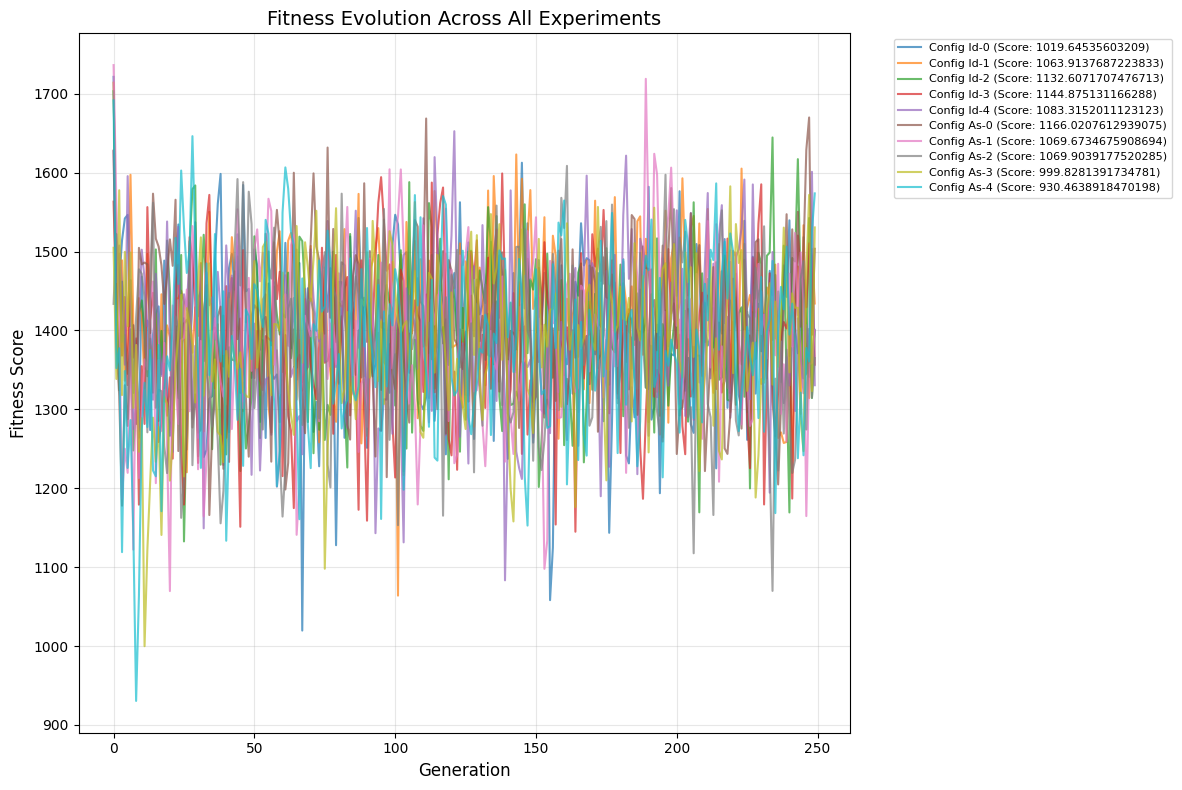

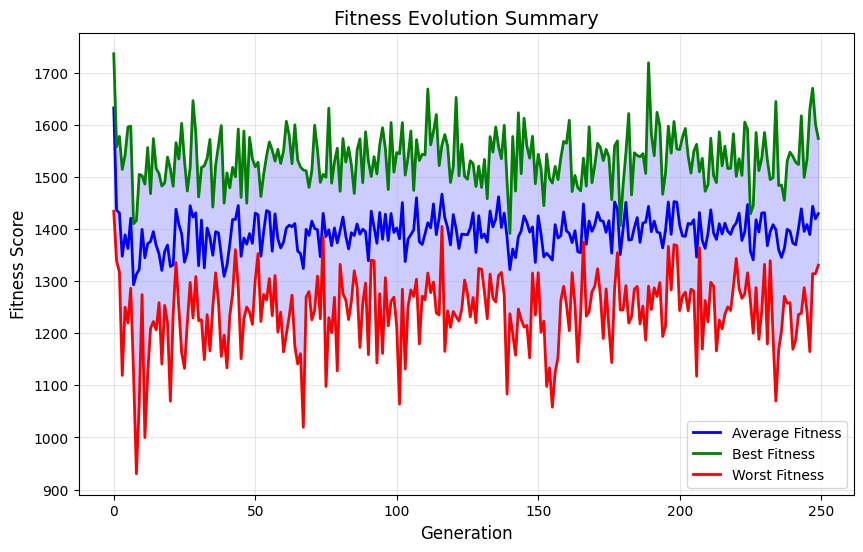

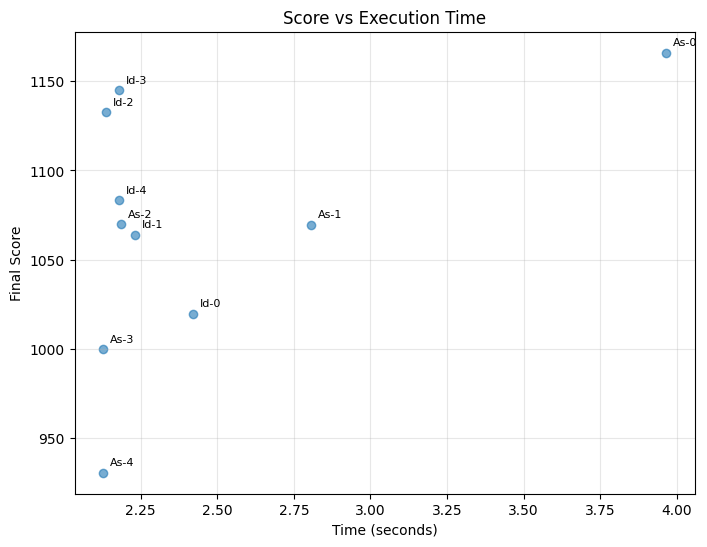

In [61]:
Basespecs = {
    "number_of_ants" : 10,
    "max_iterations" : 250,
    "alpha" : 1,
    "beta" : 3,
    "Q" : 100,
    "t_decay" : 0.95,
    "p_decay" : 0.8,
    "stag_funct" : identity,
}
speclist = [("Id",Basespecs.copy()), 
            ("As", Basespecs.copy())]
speclist[1][1]["stag_funct"] = examplestag

comparativedataset = []
for name, spec in speclist:
    comparativedataset += AnaliseConfiguration(RouteA, spec, num=5, nameprefix=name+"-")
cdf = ProcessData(comparativedataset)
ShowData(cdf)

from which we can clearly see my implementation of an anti stagnation function probably sucks, or is not given ebough time in the simulation to shive (probably the former)

similiarly we can try to see the effect of playing with decay values

____________________
####################
____________________
####################
____________________
####################
____________________
####################
____________________
####################
____________________
####################

Experiment Results Sorted by Score:
index       score       final     time
  A-1 1136.948800 1529.861459 2.194812
  D-3 1135.877056 1564.618892 2.154346
  B-3 1134.705956 1273.887788 2.204195
  F-3 1133.517382 1337.010319 2.183086
  F-0 1127.926275 1173.844584 2.187184
  C-3 1122.962560 1524.479751 2.751678
  B-0 1115.843639 1432.770372 2.138069
  C-0 1109.553306 1440.060438 2.203127
  B-1 1108.498438 1312.831341 2.161468
  C-4 1100.648303 1338.016906 2.154484
  C-1 1099.672558 1438.730490 2.180156
  D-2 1097.443211 1353.657953 2.191354
  A-4 1094.130428 1235.643785 5.008382
  C-2 1089.796103 1296.193917 4.232630
  E-4 1086.417601 1386.795085 2.208727
  B-2 1081.289018 1343.442676 2.224930
  A-3 1080.051892 1471.994669 2.431626
  E-1 107

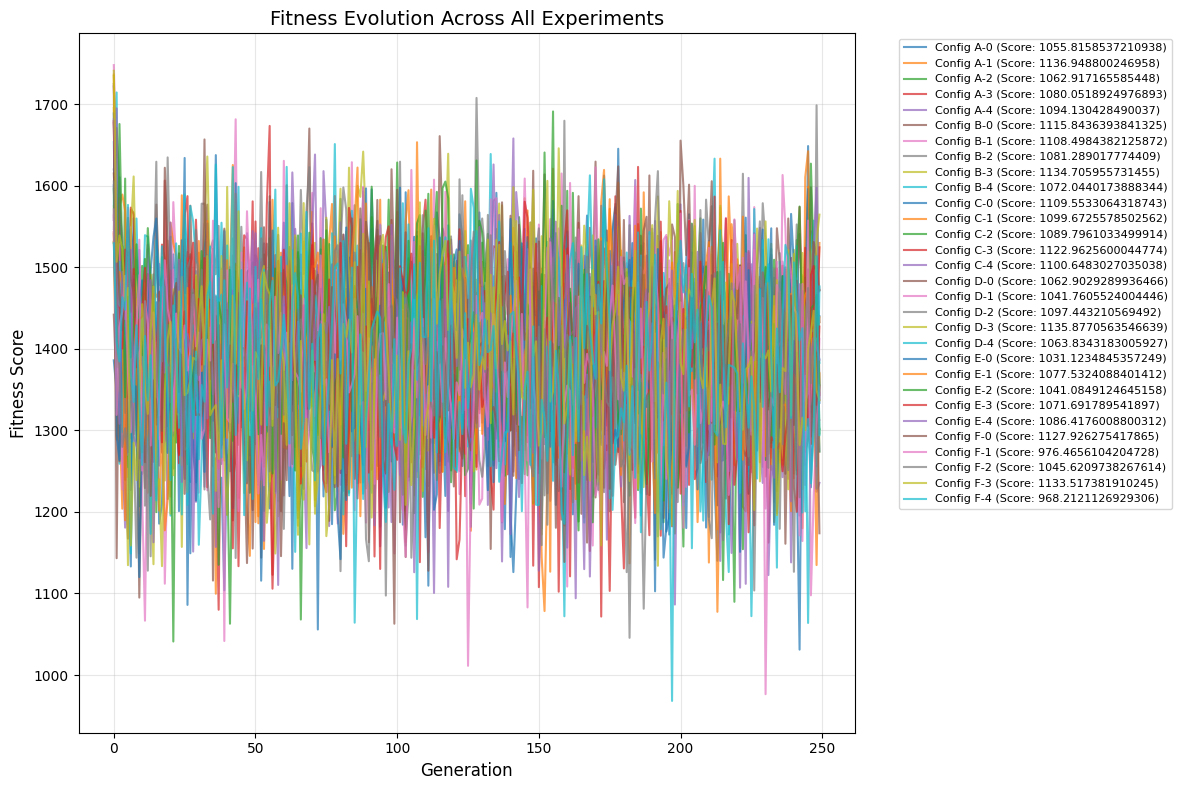

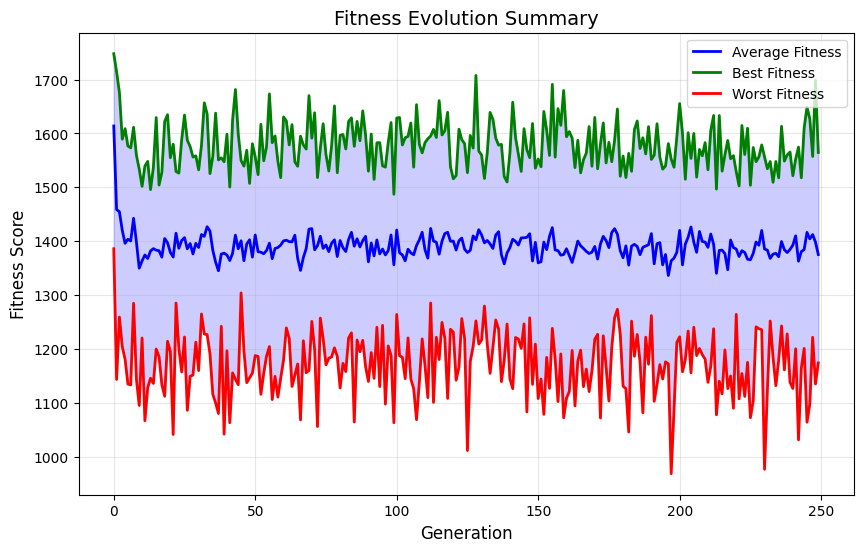

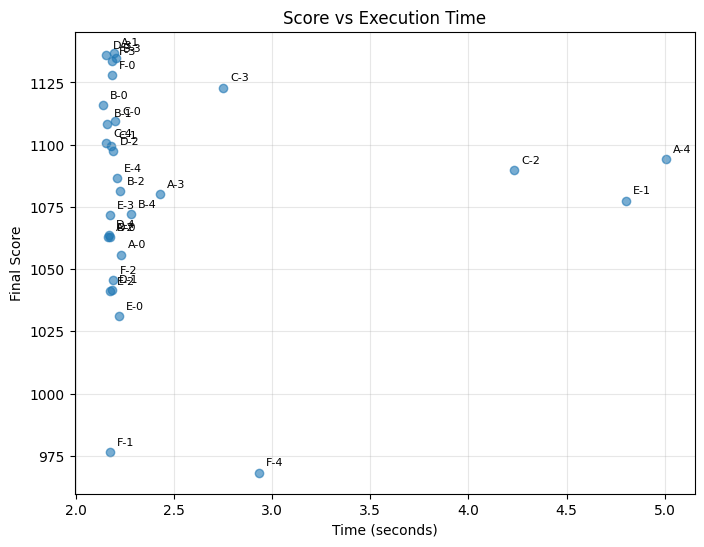

In [62]:
Basespecs = {
    "number_of_ants" : 10,
    "max_iterations" : 250,
    "alpha" : 1,
    "beta" : 3,
    "Q" : 100,
    "t_decay" : 0.95,
    "p_decay" : 0.8,
    "stag_funct" : identity,
}
speclist = [("A",Basespecs.copy()), 
            ("B", Basespecs.copy()), 
            ("C", Basespecs.copy()), 
            ("D", Basespecs.copy()), 
            ("E", Basespecs.copy()), 
            ("F", Basespecs.copy())]
speclist[1][1]["t_decay"] = 0.75
speclist[1][1]["p_decay"] = 0.95
speclist[2][1]["t_decay"] = 0.80
speclist[2][1]["p_decay"] = 0.90
speclist[3][1]["t_decay"] = 0.85
speclist[3][1]["p_decay"] = 0.85
speclist[4][1]["t_decay"] = 0.90
speclist[4][1]["p_decay"] = 0.80
speclist[5][1]["t_decay"] = 0.95
speclist[5][1]["p_decay"] = 0.75

comparativedataset = []
for name, spec in speclist:
    comparativedataset += AnaliseConfiguration(RouteA, spec, num=5, nameprefix=name+"-")
cdf = ProcessData(comparativedataset)
ShowData(cdf)

for example Here I got that $B$ has the best overall performance

and finally what is a good $Q$ value for problem A

____________________
####################
____________________
####################
____________________
####################
____________________
####################
____________________
####################

Experiment Results Sorted by Score:
index       score       final     time
  A-4 1233.383839 1583.168833 2.247718
  A-2 1215.319533 1665.313147 2.248497
  A-0 1208.844778 1630.353795 3.979347
  A-3 1187.880620 1482.266867 2.220350
  C-3 1178.222689 1414.765368 2.265580
  A-1 1174.199456 1469.029725 2.217113
  B-3 1152.811277 1290.148013 4.425746
  C-4 1127.571158 1342.298723 2.226997
  C-1 1113.622841 1519.143329 2.183382
  B-2 1113.337679 1575.560625 2.257189
  C-2 1110.868545 1212.140464 2.227105
  C-0 1103.603486 1402.137947 2.233260
  D-0 1089.106657 1474.601683 2.199145
  E-2 1086.305664 1326.108026 2.199132
  D-3 1064.008438 1380.661381 2.239213
  B-4 1063.892563 1520.767061 2.546485
  D-4 1056.540298 1413.974812 2.188621
  E-0 1045.514456 1273.616168 2.223983
  E-3 1045.0

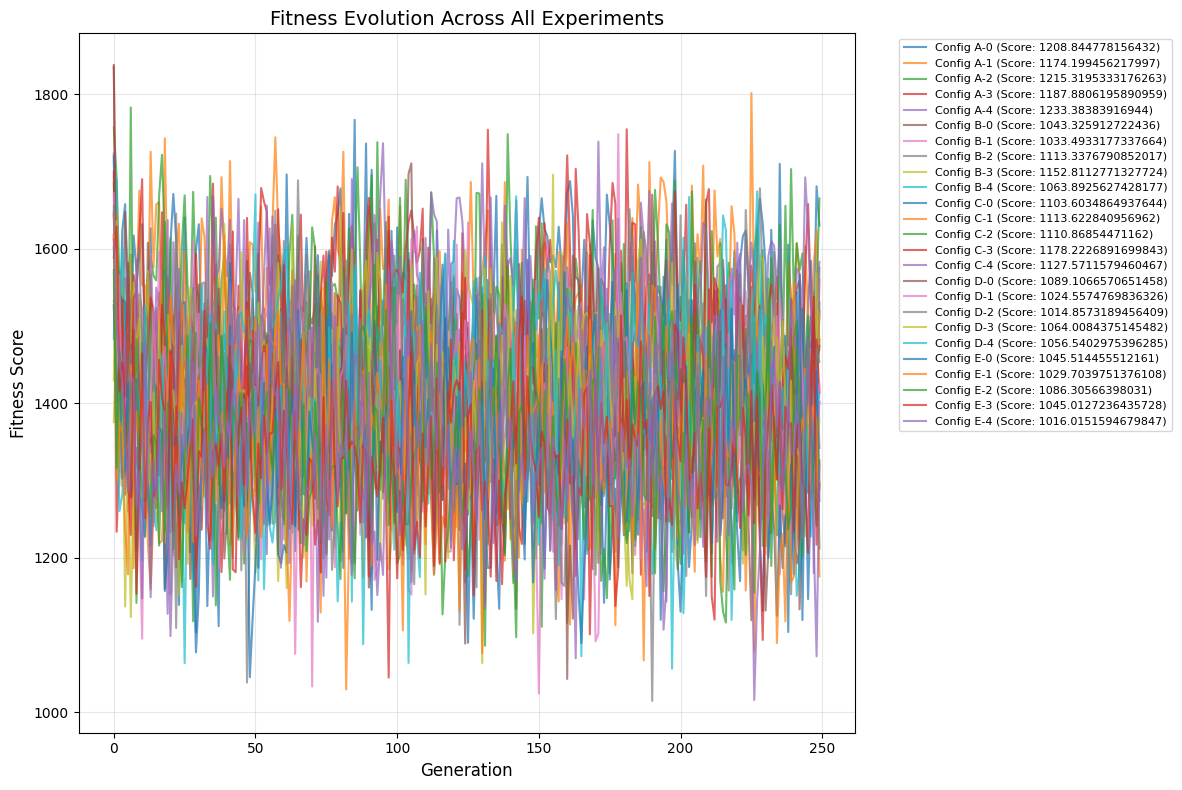

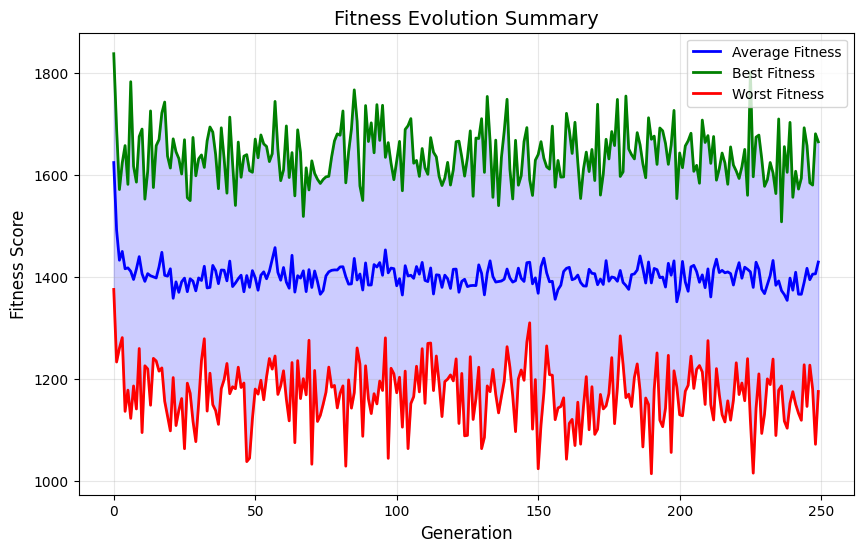

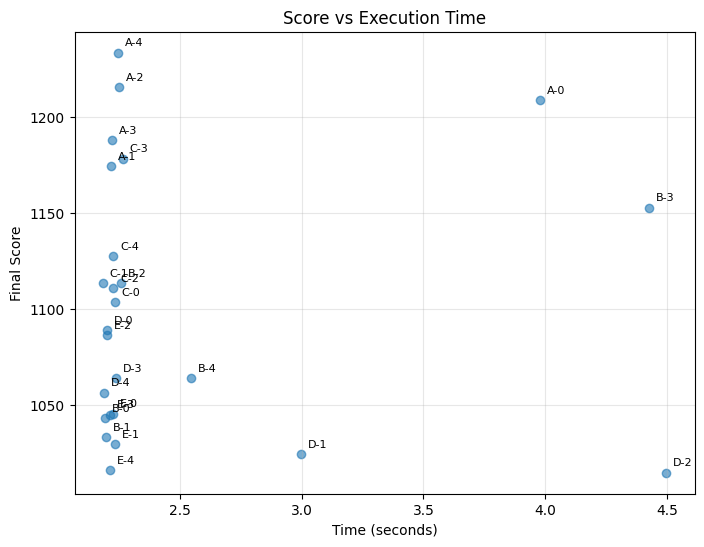

In [63]:
Basespecs = {
    "number_of_ants" : 10,
    "max_iterations" : 250,
    "alpha" : 1,
    "beta" : 3,
    "Q" : 50,
    "t_decay" : 0.95,
    "p_decay" : 0.8,
    "stag_funct" : identity,
}
speclist = [("A",Basespecs.copy()), 
            ("B", Basespecs.copy()), 
            ("C", Basespecs.copy()), 
            ("D", Basespecs.copy()), 
            ("E", Basespecs.copy())]
speclist[1][1]["Q"] = 75
speclist[2][1]["Q"] = 100
speclist[3][1]["Q"] = 125
speclist[4][1]["Q"] = 150

comparativedataset = []
for name, spec in speclist:
    comparativedataset += AnaliseConfiguration(RouteA, spec, num=5, nameprefix=name+"-")
cdf = ProcessData(comparativedataset)
ShowData(cdf)

which implies that higher values of $Q$ are ideal, for this specific case, looking over how the algorithm works, I myself would guess $Q$ should be linear in relation to the sum of distances to the depot, or another similiar value, though the exact relation I am quite unsure of